In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
from scipy import stats

In [2]:
mlb_pitchers = pd.read_csv('All Pitchers Cleaned.csv')
mlb_pitchers

,Player,Debut Year,Debut Age,Retirement Year,Retirement Age,Career Length,Wins,Losses,Win Percentage,Total Decisions,...,BF,ERA+,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Hall of Fame
0,Cy Young,1890,23,1911,44,21,511,315,0.619,826,...,29565,138,2.84,1.130,8.7,0.2,1.5,3.4,2.30,1
1,Pud Galvin,1875,18,1892,35,17,365,310,0.541,675,...,25415,107,2.96,1.191,9.6,0.2,1.1,2.7,2.43,1
2,Walter Johnson,1907,19,1927,39,20,417,279,0.599,696,...,23415,147,2.38,1.061,7.5,0.1,2.1,5.3,2.57,1
3,Phil Niekro,1964,25,1987,48,23,318,274,0.537,592,...,22677,115,3.62,1.268,8.4,0.8,3.0,5.6,1.85,1
4,Nolan Ryan,1966,19,1993,46,27,324,292,0.526,616,...,22575,112,2.97,1.247,6.6,0.5,4.7,9.5,2.04,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,Charlie Robertson,1919,23,1928,32,9,49,80,0.380,129,...,4453,90,3.89,1.518,10.3,0.3,3.4,2.8,0.82,0
1211,Sammy Ellis,1962,21,1969,28,7,63,58,0.521,121,...,4296,88,3.90,1.340,8.7,1.1,3.4,6.1,1.79,0
1212,Lil Stoner,1922,23,1931,32,9,50,57,0.467,107,...,4466,87,4.13,1.548,10.6,0.6,3.4,2.7,0.80,0
1213,Johnny Humphries,1938,23,1946,31,8,52,63,0.452,115,...,4342,97,3.80,1.394,9.2,0.4,3.4,2.8,0.85,0


# K-Fold and GridSearch

In [27]:
etc = ExtraTreesClassifier()

# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

etc.fit(X_train, y_train)

ExtraTreesClassifier()

In [34]:
%%time

# Define two types of K-Fold Cross Validation strategies so that either one can be used
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define model
etc = ExtraTreesClassifier()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [False],
    'class_weight': [None, 'balanced']
}

# Define GridSearchCV with KFold
grid_search = GridSearchCV(
    estimator=etc,
    param_grid=param_grid,
    cv=kf,
    scoring='precision',
    n_jobs=-1
)

# Fit on your training data
grid_search.fit(X_train, y_train)

# Best model
#best_model = grid_search.best_estimator_
etc_best = grid_search.best_estimator_
etc_best.fit(X_train, y_train)

CPU times: user 524 ms, sys: 213 ms, total: 737 ms
Wall time: 7.16 s


ExtraTreesClassifier(class_weight='balanced', max_features='log2',
                     n_estimators=200)

In [35]:
import joblib
#joblib.dump(etc_best, 'stored_models/model_etc_best_recall_stratified_kfold.sav')
#joblib.dump(etc_best, 'stored_models/model_etc_best_f1_stratified_kfold.sav')
#joblib.dump(etc_best, 'stored_models/model_etc_best_f1_standard_kfold.sav')
#joblib.dump(etc_best, 'stored_models/model_etc_best_recall_standard_kfold.sav')
#joblib.dump(etc_best, 'stored_models/model_etc_best_precision_standard_kfold.sav')
#joblib.dump(etc_best, 'stored_models/model_etc_best_precision_stratified_kfold.sav')

['stored_models/model_etc_best_precision_standard_kfold.sav']

In [23]:
#joblib.load(etc_best, 'stored_models/model_etc_best_recall_stratified_kfold.sav')
#joblib.load(etc_best, 'stored_models/model_etc_best_f1_stratified_kfold.sav')
#joblib.load(etc_best, 'stored_models/model_etc_best_f1_standard_kfold.sav')
#joblib.load(etc_best, 'stored_models/model_etc_best_recall_standard_kfold.sav')

In [36]:
# Define the same KFold strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Get out-of-fold predictions using the tuned model
y_pred_all_best = cross_val_predict(etc_best, X, y, cv=kf)

# Get predicted probabilities
y_proba_all_best = cross_val_predict(etc_best, X, y, cv=kf, method='predict_proba')

# Regular predictions
y_pred_all_best = cross_val_predict(etc_best, X, y, cv=kf)

# If binary classification, pick the probability of the predicted class
# (confidence in whichever class was chosen)
y_pred_indices = np.array([list(np.unique(y)).index(p) for p in y_pred_all_best])
confidence_scores = y_proba_all_best[np.arange(len(y_proba_all_best)), y_pred_indices]

# Build results dataframe
etc_gs_results = pd.DataFrame()
etc_gs_results['Player'] = mlb_pitchers['Player']
etc_gs_results['Hall of Fame'] = y
etc_gs_results['Prediction'] = y_pred_all_best
etc_gs_results['Prediction Correct'] = (etc_gs_results['Hall of Fame'] == etc_gs_results['Prediction']).astype(int)
etc_gs_results['Prediction Confidence'] = confidence_scores
etc_gs_results

,Player,Hall of Fame,Prediction,Prediction Correct,Prediction Confidence
0,Cy Young,1,1,1,0.905
1,Pud Galvin,1,1,1,0.645
2,Walter Johnson,1,1,1,0.910
3,Phil Niekro,1,1,1,0.735
4,Nolan Ryan,1,1,1,0.810
...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.000
1211,Sammy Ellis,0,0,1,1.000
1212,Lil Stoner,0,0,1,1.000
1213,Johnny Humphries,0,0,1,1.000


In [37]:
#etc_gs_results.to_csv('stored_results/Results_ETC_GS_Best_Recall_Stratified_KFold.csv', index=False)
#etc_gs_results.to_csv('stored_results/Results_ETC_GS_Best_F1_Stratified_KFold.csv', index=False)
#etc_gs_results.to_csv('stored_results/Results_ETC_GS_Best_Recall_Standard_KFold.csv', index=False)
#etc_gs_results.to_csv('stored_results/Results_ETC_GS_Best_F1_Standard_KFold.csv', index=False)
#etc_gs_results.to_csv('stored_results/Results_ETC_GS_Best_Precision_Standard_KFold.csv', index=False)
#etc_gs_results.to_csv('stored_results/Results_ETC_GS_Best_Precision_Stratified_KFold.csv', index=False)

In [ ]:
# Run this cell to generate a classification report with metrics and visuals

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

def show_summary_report(actual, prediction):
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    prediction = prediction.astype(float)
    prediction_int = np.round(prediction)

    print('Accuracy : %.4f [TP / N]         Best: 1, Worst: 0' %
          accuracy_score(actual, prediction_int))
    print('           Percentage of all predictions that were correct.')

    print('Precision: %.4f [TP / (TP + FP)] Best: 1, Worst: 0' %
          precision_score(actual, prediction_int))
    print('           Percent of Positive predictions that were correct. Minimizes false positives.')

    print('Recall   : %.4f [TP / (TP + FN)] Best: 1, Worst: 0' %
          recall_score(actual, prediction_int))
    print('           Percent of True instances that were identified as such. Minimizes false negatives.')

    print('F1 Score : %.4f [(2 * P * R) / (P + R)]  Best: 1, Worst: 0' %
          f1_score(actual, prediction_int))
    print('           Harmonic mean of Precision and Recall.\n           Finds a balance in minimizing both false positives and false negatives.')

    print('ROC AUC  : %.4f                  Best: 1, Worst: < 0.5' %
          roc_auc_score(actual, prediction))

    print('-' * 80)
    print('TP: True Positives, FP: False Positives,')
    print('TN: True Negatives, FN: False Negatives,')
    print('N: Number of samples')

    # Confusion Matrix
    mat = confusion_matrix(actual, prediction_int, labels=[0, 1])

    # Precision/Recall
    precision, recall, _ = precision_recall_curve(actual, prediction)

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)

    # plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(left=0.02, right=0.98, wspace=0.2)

    # Confusion Matrix (no .T)
    sns.heatmap(mat, square=True, annot=True, fmt='d',
                cbar=False, cmap='Greens', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted label')
    ax[0].set_ylabel('True label')

    # Precision/Recall
    step_kwargs = {'step': 'post'}
    ax[1].step(recall, precision, color='r', alpha=0.2, where='post')
    ax[1].fill_between(recall, precision, alpha=0.2, color='r', **step_kwargs)
    ax[1].set_ylim([0.0, 1.0])
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('2-class Precision-Recall curve')

    # ROC
    ax[2].plot(fpr, tpr, color='darkorange', lw=2,
               label='ROC curve (AUC = %0.2f)' % roc_auc)
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlim([0.0, 1.0])
    ax[2].set_ylim([0.0, 1.0])
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('Receiver Operating Characteristic')
    ax[2].legend(loc='lower right')

    plt.show()


show_summary_report(y, y_pred_all)

# Old version with no GridSearch

In [36]:
etc = ExtraTreesClassifier()

# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

etc.fit(X_train, y_train)

ExtraTreesClassifier()

In [37]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for all data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(etc, X, y, cv=kf)


# Get predicted probabilities
y_proba_all = cross_val_predict(etc, X, y, cv=kf, method='predict_proba')

# Regular predictions
y_pred_all = cross_val_predict(etc, X, y, cv=kf)


# If binary classification, pick the probability of the predicted class
# (confidence in whichever class was chosen)
y_pred_indices = np.array([list(np.unique(y)).index(p) for p in y_pred_all])
confidence_scores = y_proba_all[np.arange(len(y_proba_all)), y_pred_indices]

# Build results dataframe
etc_cv_results = pd.DataFrame()
etc_cv_results['Player'] = mlb_pitchers['Player']
etc_cv_results['Hall of Fame'] = y
etc_cv_results['Prediction'] = y_pred_all
etc_cv_results['Prediction Correct'] = (etc_cv_results['Hall of Fame'] == etc_cv_results['Prediction']).astype(int)
etc_cv_results['Prediction Confidence'] = confidence_scores

#df['percentage_of_max'] = (df['values'] / max_value) * 100

etc_cv_results

,Player,Hall of Fame,Prediction,Prediction Correct,Prediction Confidence
0,Cy Young,1,1,1,0.97
1,Pud Galvin,1,1,1,0.77
2,Walter Johnson,1,1,1,0.94
3,Phil Niekro,1,1,1,0.80
4,Nolan Ryan,1,1,1,0.89
...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.00
1211,Sammy Ellis,0,0,1,1.00
1212,Lil Stoner,0,0,1,1.00
1213,Johnny Humphries,0,0,1,1.00


In [32]:
#etc_cv_results.to_csv('Results_ETC_no_GS.csv', index=False)

# More extensive param_grid
Didn't run after 20 minutes

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [False, True],
    'class_weight': [None, 'balanced']
}

# Prediction Score Ideas

In [5]:
# signed score (you already have)
etc_cv_results['ETC Prediction Score'] = np.where(
    etc_cv_results['ETC Correct'] == 1,
    etc_cv_results['ETC Confidence'],
    -etc_cv_results['ETC Confidence']
)

# Option 2: rescale signed score to [0,1]
etc_cv_results['ETC Rescaled Prediction Score'] = (1 + etc_cv_results['ETC Prediction Score']) / 2

etc_cv_results

,Player,Hall of Fame,ETC Prediction,ETC Correct,ETC Confidence,ETC Prediction Score,ETC Rescaled Prediction Score
0,Cy Young,1,1,1,0.97,0.97,0.985
1,Pud Galvin,1,1,1,0.79,0.79,0.895
2,Walter Johnson,1,1,1,0.93,0.93,0.965
3,Phil Niekro,1,1,1,0.85,0.85,0.925
4,Nolan Ryan,1,1,1,0.88,0.88,0.940
...,...,...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.00,1.00,1.000
1211,Sammy Ellis,0,0,1,1.00,1.00,1.000
1212,Lil Stoner,0,0,1,1.00,1.00,1.000
1213,Johnny Humphries,0,0,1,1.00,1.00,1.000


In [8]:
etc_cv_results.nsmallest(10, 'ETC Rescaled Prediction Score')

,Player,Hall of Fame,ETC Prediction,ETC Correct,ETC Confidence,ETC Prediction Score,ETC Rescaled Prediction Score
105,Jesse Haines,1,0,0,0.95,-0.95,0.025
15,Roger Clemens,0,1,0,0.93,-0.93,0.035
152,Jack Chesbro,1,0,0,0.93,-0.93,0.035
449,Dizzy Dean,1,0,0,0.89,-0.89,0.055
91,Rube Marquard,1,0,0,0.87,-0.87,0.065
653,Andy Cooper,1,0,0,0.87,-0.87,0.065
246,Lefty Gomez,1,0,0,0.86,-0.86,0.070
158,Bob Lemon,1,0,0,0.85,-0.85,0.075
986,Babe Ruth,1,0,0,0.84,-0.84,0.080
19,Tommy John,0,1,0,0.81,-0.81,0.095


# Which correct prediction had the lowest confidence?

In [10]:
corr_pred = etc_cv_results[etc_cv_results['ETC Correct'] == 1]
corr_pred.nsmallest(10, 'ETC Confidence')

,Player,Hall of Fame,ETC Prediction,ETC Correct,ETC Confidence,ETC Prediction Score,ETC Rescaled Prediction Score
41,Vic Willis,1,1,1,0.44,0.44,0.720
29,Tom Glavine,1,1,1,0.50,0.50,0.750
84,Clark Griffith,0,0,1,0.52,0.52,0.760
101,Eddie Cicotte,0,0,1,0.52,0.52,0.760
36,Ted Lyons,1,1,1,0.55,0.55,0.775
90,Andy Pettitte,0,0,1,0.55,0.55,0.775
569,Satchel Paige,1,1,1,0.55,0.55,0.775
66,Mike Mussina,1,1,1,0.56,0.56,0.780
51,Amos Rusie,1,1,1,0.57,0.57,0.785
12,Greg Maddux,1,1,1,0.58,0.58,0.790


# Reward low-confidence correct predictions, punish high-confidence incorrect predictions.

Alpha-adjusted.

In [12]:
import numpy as np

# assume etc_cv_results exists and has these columns:
# 'ETC Confidence' (confidence for predicted class, float 0..1)
# 'ETC Correct' (1 if correct, 0 if wrong)

def scoring_tuned(conf, correct, alpha=0.5):
    """
    Returns score in [0,1] where higher is better.
    alpha controls strength; default 0.5 matches the example discussed.
    """
    if correct:
        return 1.0 - alpha * conf
    else:
        return (1.0 - alpha) * (1.0 - conf)

# vectorized for pandas
alpha = 0.5
conf = etc_cv_results['ETC Confidence'].values
correct = etc_cv_results['ETC Correct'].values.astype(bool)

# compute scores
scores = np.where(
    correct,
    1.0 - alpha * conf,
    (1.0 - alpha) * (1.0 - conf)
)

etc_cv_results['ETC CustomScore'] = scores

etc_cv_results

,Player,Hall of Fame,ETC Prediction,ETC Correct,ETC Confidence,ETC Prediction Score,ETC Rescaled Prediction Score,ETC CustomScore
0,Cy Young,1,1,1,0.97,0.97,0.985,0.515
1,Pud Galvin,1,1,1,0.79,0.79,0.895,0.605
2,Walter Johnson,1,1,1,0.93,0.93,0.965,0.535
3,Phil Niekro,1,1,1,0.85,0.85,0.925,0.575
4,Nolan Ryan,1,1,1,0.88,0.88,0.940,0.560
...,...,...,...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.00,1.00,1.000,0.500
1211,Sammy Ellis,0,0,1,1.00,1.00,1.000,0.500
1212,Lil Stoner,0,0,1,1.00,1.00,1.000,0.500
1213,Johnny Humphries,0,0,1,1.00,1.00,1.000,0.500


In [16]:
etc_cv_results.nsmallest(10, 'ETC Confidence')

,Player,Hall of Fame,ETC Prediction,ETC Correct,ETC Confidence,ETC Prediction Score,ETC Rescaled Prediction Score,ETC CustomScore
133,Charles Bender,1,0,0,0.41,-0.41,0.295,0.295
113,Whitey Ford,1,0,0,0.43,-0.43,0.285,0.285
24,Jim Kaat,1,0,0,0.44,-0.44,0.280,0.280
41,Vic Willis,1,1,1,0.44,0.44,0.720,0.780
785,Smoky Joe Wood,0,1,0,0.47,-0.47,0.265,0.265
29,Tom Glavine,1,1,1,0.50,0.50,0.750,0.750
84,Clark Griffith,0,0,1,0.52,0.52,0.760,0.740
101,Eddie Cicotte,0,0,1,0.52,0.52,0.760,0.740
294,Addie Joss,1,0,0,0.52,-0.52,0.240,0.240
36,Ted Lyons,1,1,1,0.55,0.55,0.775,0.725


In [17]:
etc_cv_results.nlargest(10, 'ETC CustomScore')

,Player,Hall of Fame,ETC Prediction,ETC Correct,ETC Confidence,ETC Prediction Score,ETC Rescaled Prediction Score,ETC CustomScore
41,Vic Willis,1,1,1,0.44,0.44,0.720,0.780
29,Tom Glavine,1,1,1,0.50,0.50,0.750,0.750
84,Clark Griffith,0,0,1,0.52,0.52,0.760,0.740
101,Eddie Cicotte,0,0,1,0.52,0.52,0.760,0.740
36,Ted Lyons,1,1,1,0.55,0.55,0.775,0.725
90,Andy Pettitte,0,0,1,0.55,0.55,0.775,0.725
569,Satchel Paige,1,1,1,0.55,0.55,0.775,0.725
66,Mike Mussina,1,1,1,0.56,0.56,0.780,0.720
51,Amos Rusie,1,1,1,0.57,0.57,0.785,0.715
12,Greg Maddux,1,1,1,0.58,0.58,0.790,0.710


In [25]:
etc_cv_results['ETC 3 Score Average'] = (etc_cv_results['ETC Prediction Score'] + etc_cv_results['ETC Rescaled Prediction Score'] + etc_cv_results['ETC CustomScore']) / 3
etc_cv_results

,Player,Hall of Fame,ETC Prediction,ETC Correct,ETC Confidence,ETC Prediction Score,ETC Rescaled Prediction Score,ETC CustomScore,ETC 3 Score Average
0,Cy Young,1,1,1,0.97,0.97,0.985,0.515,0.823333
1,Pud Galvin,1,1,1,0.79,0.79,0.895,0.605,0.763333
2,Walter Johnson,1,1,1,0.93,0.93,0.965,0.535,0.810000
3,Phil Niekro,1,1,1,0.85,0.85,0.925,0.575,0.783333
4,Nolan Ryan,1,1,1,0.88,0.88,0.940,0.560,0.793333
...,...,...,...,...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.00,1.00,1.000,0.500,0.833333
1211,Sammy Ellis,0,0,1,1.00,1.00,1.000,0.500,0.833333
1212,Lil Stoner,0,0,1,1.00,1.00,1.000,0.500,0.833333
1213,Johnny Humphries,0,0,1,1.00,1.00,1.000,0.500,0.833333


In [27]:
etc_cv_results.nsmallest(10, 'ETC 3 Score Average')

,Player,Hall of Fame,ETC Prediction,ETC Correct,ETC Confidence,ETC Prediction Score,ETC Rescaled Prediction Score,ETC CustomScore,ETC 3 Score Average
105,Jesse Haines,1,0,0,0.95,-0.95,0.025,0.025,-0.300000
15,Roger Clemens,0,1,0,0.93,-0.93,0.035,0.035,-0.286667
152,Jack Chesbro,1,0,0,0.93,-0.93,0.035,0.035,-0.286667
449,Dizzy Dean,1,0,0,0.89,-0.89,0.055,0.055,-0.260000
91,Rube Marquard,1,0,0,0.87,-0.87,0.065,0.065,-0.246667
653,Andy Cooper,1,0,0,0.87,-0.87,0.065,0.065,-0.246667
246,Lefty Gomez,1,0,0,0.86,-0.86,0.070,0.070,-0.240000
158,Bob Lemon,1,0,0,0.85,-0.85,0.075,0.075,-0.233333
986,Babe Ruth,1,0,0,0.84,-0.84,0.080,0.080,-0.226667
19,Tommy John,0,1,0,0.81,-0.81,0.095,0.095,-0.206667


# Classification Report

Accuracy : 0.9630 [TP / N]         Best: 1, Worst: 0
           Percentage of all predictions that were correct.
Precision: 0.8136 [TP / (TP + FP)] Best: 1, Worst: 0
           Percent of Positive predictions that were correct. Minimizes false positives.
Recall   : 0.5854 [TP / (TP + FN)] Best: 1, Worst: 0
           Percent of Positive instances that were identified as such. Minimizes false negatives.
F1 Score : 0.6809 [2PR / (P + R)]  Best: 1, Worst: 0
           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.
ROC AUC  : 0.7878                  Best: 1, Worst: < 0.5
--------------------------------------------------------------------------------
TP: True Positives, FP: False Positives,
TN: True Negatives, FN: False Negatives,
N: Number of samples


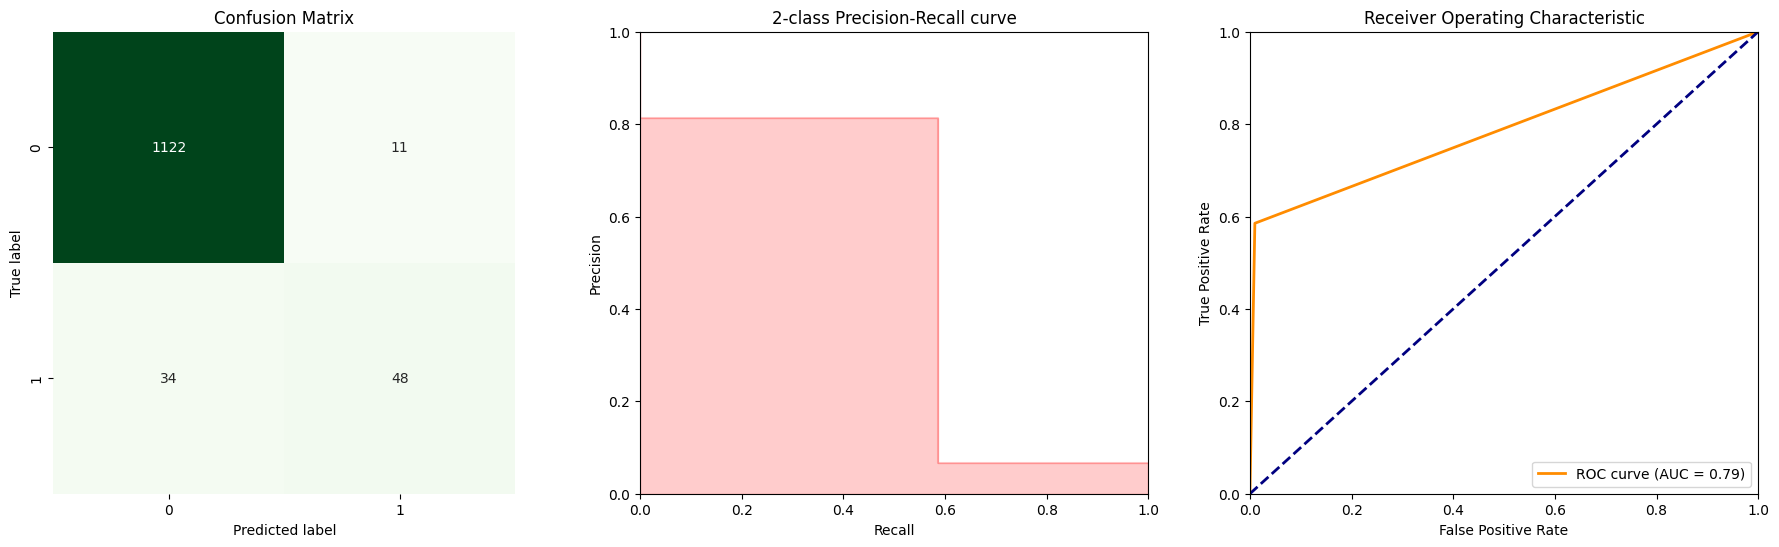

In [24]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

def show_summary_report(actual, prediction):
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    prediction = prediction.astype(float)
    prediction_int = np.round(prediction)

    print('Accuracy : %.4f [TP / N]         Best: 1, Worst: 0' %
          accuracy_score(actual, prediction_int))
    print('           Percentage of all predictions that were correct.')

    print('Precision: %.4f [TP / (TP + FP)] Best: 1, Worst: 0' %
          precision_score(actual, prediction_int))
    print('           Percent of Positive predictions that were correct. Minimizes false positives.')

    print('Recall   : %.4f [TP / (TP + FN)] Best: 1, Worst: 0' %
          recall_score(actual, prediction_int))
    print('           Percent of Positive instances that were identified as such. Minimizes false negatives.')

    print('F1 Score : %.4f [2PR / (P + R)]  Best: 1, Worst: 0' %
          f1_score(actual, prediction_int))
    print('           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.')

    print('ROC AUC  : %.4f                  Best: 1, Worst: < 0.5' %
          roc_auc_score(actual, prediction))

    print('-' * 80)
    print('TP: True Positives, FP: False Positives,')
    print('TN: True Negatives, FN: False Negatives,')
    print('N: Number of samples')

    # Confusion Matrix
    mat = confusion_matrix(actual, prediction_int, labels=[0, 1])

    # Precision/Recall
    precision, recall, _ = precision_recall_curve(actual, prediction)

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)

    # plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(left=0.02, right=0.98, wspace=0.2)

    # Confusion Matrix (no .T)
    sns.heatmap(mat, square=True, annot=True, fmt='d',
                cbar=False, cmap='Greens', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted label')
    ax[0].set_ylabel('True label')

    # Precision/Recall
    step_kwargs = {'step': 'post'}
    ax[1].step(recall, precision, color='r', alpha=0.2, where='post')
    ax[1].fill_between(recall, precision, alpha=0.2, color='r', **step_kwargs)
    ax[1].set_ylim([0.0, 1.0])
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('2-class Precision-Recall curve')

    # ROC
    ax[2].plot(fpr, tpr, color='darkorange', lw=2,
               label='ROC curve (AUC = %0.2f)' % roc_auc)
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlim([0.0, 1.0])
    ax[2].set_ylim([0.0, 1.0])
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('Receiver Operating Characteristic')
    ax[2].legend(loc='lower right')

    plt.show()


show_summary_report(y, y_pred_all)